<a href="https://colab.research.google.com/github/Alenushka2013/Kaggle-experiments/blob/main/Flight_Session2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Время летать - занятие 2

## Введение в машинное обучение. Задача регрессии


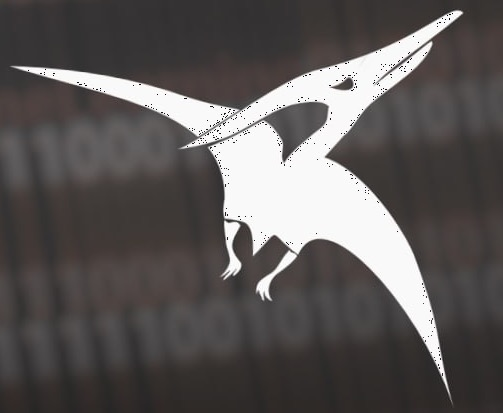

Цели ноутбука:

* Научиться обучать линейную регрессию и оценивать ее качество

Будем обучать регрессию для прогнозирования возраста крабов по их различным характеристикам!

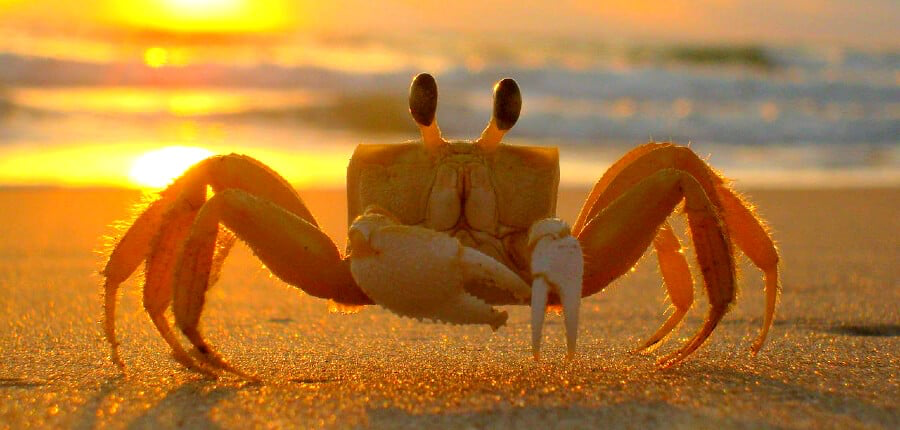

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/aiedu-courses/all_datasets/main/CrabeAge.csv")

Описание данных (из оригинального источника):

* Sex	(object) - gender of the crab (Male, Female, Intermediate)

* Length (float) - length of the crab, in foot

* Diameter (float) - diameter of the crab, in foot

* Height (float) - height of the crab, in foot

* Weight (float) - weight of the crab, in ounces

* Shucked Weight (float) - weight without the shell, in ounces

* Viscera Weight (float) - deep abdominal organs weight, in ounces

* Shell Weight (float) - weight of the shell, in ounces

* Age	(int)	- age of the crab, in months

In [ ]:
df.head()

,Sex,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
0,F,1.4375,1.1750,0.4125,24.635715,12.332033,5.584852,6.747181,9
1,M,0.8875,0.6500,0.2125,5.400580,2.296310,1.374951,1.559222,6
2,I,1.0375,0.7750,0.2500,7.952035,3.231843,1.601747,2.764076,6
3,F,1.1750,0.8875,0.2500,13.480187,4.748541,2.282135,5.244657,10
4,I,0.8875,0.6625,0.2125,6.903103,3.458639,1.488349,1.700970,6


In [ ]:
df.shape

(3893, 9)

Сформируем матрицу объект-признак `X` и вектор целевой переменной `y`.

In [ ]:
X = df.drop(['Sex', 'Age'], axis=1) # матрица объект-признак
y = df['Age'] # target

X.head()

,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight
0,1.4375,1.1750,0.4125,24.635715,12.332033,5.584852,6.747181
1,0.8875,0.6500,0.2125,5.400580,2.296310,1.374951,1.559222
2,1.0375,0.7750,0.2500,7.952035,3.231843,1.601747,2.764076
3,1.1750,0.8875,0.2500,13.480187,4.748541,2.282135,5.244657
4,0.8875,0.6625,0.2125,6.903103,3.458639,1.488349,1.700970


Разобъем данные на обучающую и тестовую части.

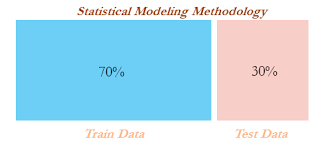

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

X_train.shape, X_test.shape

((2919, 7), (974, 7))

### Обучим линейную регрессию

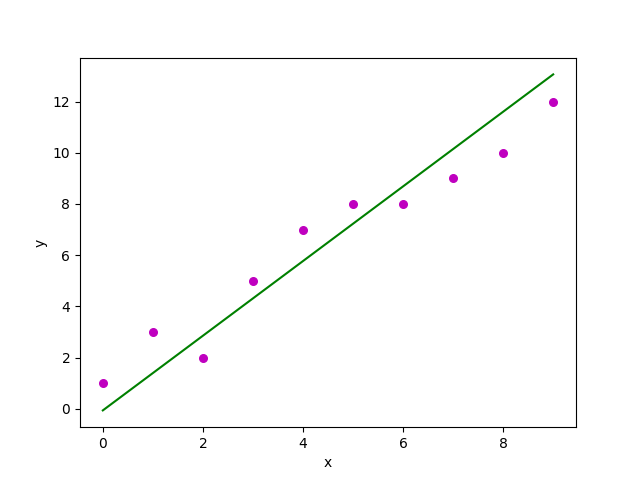

Линейная регрессия прогнозирует целевую переменную по формуле

$$a(x) = w_0 + w_1x_1 + w_2x_2 + ... +w_dx_d,$$
где

* $x_1, x_2, ..., x_d$ - признаки объекта

* $w_0, w_1, ..., w_d$ - веса модели (подбираются автоматически в процессе обучения)

* $a(x)$ - прогноз целевой переменной на объекте $x$.

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

Оценим качество прогноза

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

pred = model.predict(X_test)

pred[:10]

array([ 6.61836162,  8.04018451,  8.89889775,  9.68620033,  6.65055555,
       15.85130477, 10.82970586, 12.8720049 ,  9.68616597,  7.48446699])

In [ ]:
y_test[:10].values

array([ 6,  8, 11,  9,  6, 16, 13, 13,  8,  9])

In [ ]:
mean_squared_error(y_test, pred) ** 0.5 # RMSE

2.1996910496301276

<Axes: >

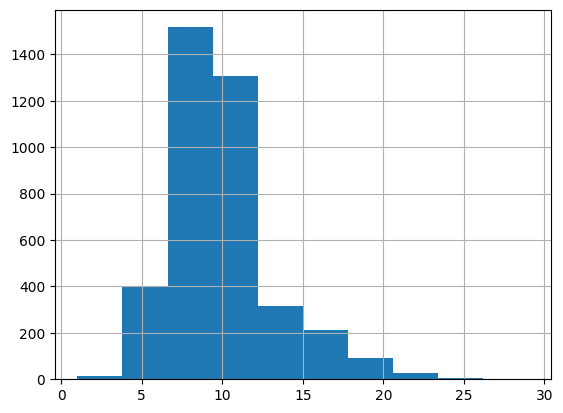

In [ ]:
df['Age'].hist()

## Метрики качества в задаче регрессии

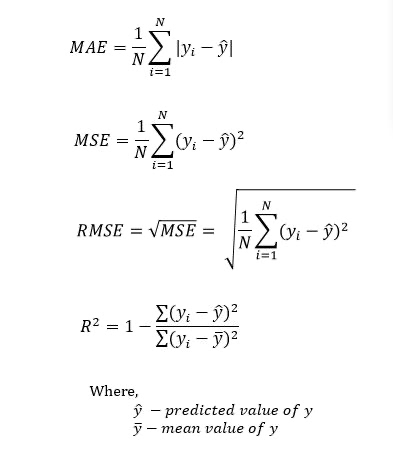

In [ ]:
r2_score(y_test, pred)

0.5118114889219193

Есть ли переобучение?

In [ ]:
pred_train = model.predict(X_train)

r2_score(y_train, pred_train)

0.5286915136349506

Переобучения нет. Будем пытаться улучшить качество модели.

### Добавление категориального признака

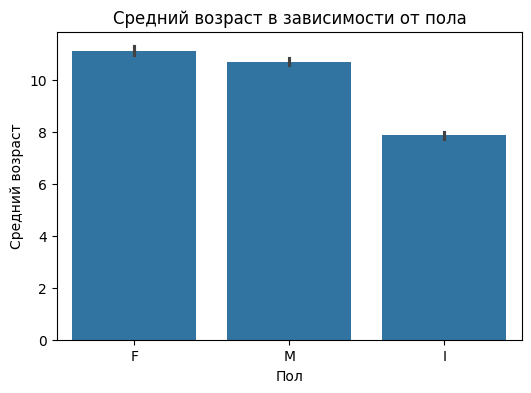

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.barplot(x='Sex', y='Age', data=df)

plt.title('Средний возраст в зависимости от пола')
plt.xlabel('Пол')
plt.ylabel('Средний возраст')

plt.show()

One-Hot кодирование

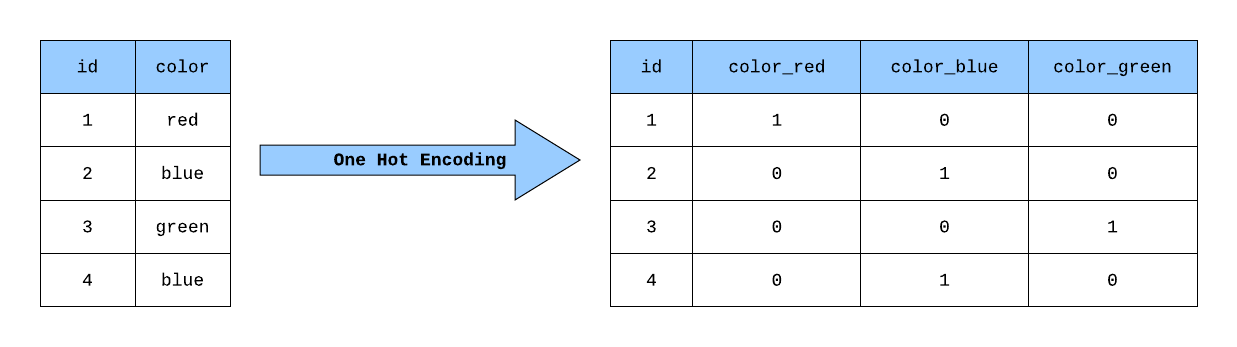

In [ ]:
df_encoded = pd.get_dummies(df, columns=['Sex'], drop_first = True, dtype = int)

df_encoded.head()

,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age,Sex_I,Sex_M
0,1.4375,1.1750,0.4125,24.635715,12.332033,5.584852,6.747181,9,0,0
1,0.8875,0.6500,0.2125,5.400580,2.296310,1.374951,1.559222,6,0,1
2,1.0375,0.7750,0.2500,7.952035,3.231843,1.601747,2.764076,6,1,0
3,1.1750,0.8875,0.2500,13.480187,4.748541,2.282135,5.244657,10,0,0
4,0.8875,0.6625,0.2125,6.903103,3.458639,1.488349,1.700970,6,1,0


In [ ]:
X_enc = df_encoded.drop(['Age'], axis=1)
y_enc = df_encoded['Age']

X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(X_enc, y_enc, test_size=0.25, random_state=42)

In [ ]:
model.fit(X_train_enc, y_train_enc)

pred_enc = model.predict(X_test_enc)

In [ ]:
r2_score(y_test_enc, pred_enc)

0.5192632383282014

Качество немного возросло.

## Обработка выбросов

In [ ]:
df.describe()

,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
count,3893.000000,3893.000000,3893.000000,3893.000000,3893.000000,3893.000000,3893.000000,3893.000000
mean,1.311306,1.020893,0.349374,23.567275,10.207342,5.136546,6.795844,9.954791
std,0.300431,0.248233,0.104976,13.891201,6.275275,3.104133,3.943392,3.220967
min,0.187500,0.137500,0.000000,0.056699,0.028349,0.014175,0.042524,1.000000
25%,1.125000,0.875000,0.287500,12.672227,5.343881,2.664853,3.713785,8.000000
50%,1.362500,1.062500,0.362500,22.792998,9.539607,4.861939,6.662133,10.000000
75%,1.537500,1.200000,0.412500,32.786197,14.273973,7.200773,9.355335,11.000000
max,2.037500,1.625000,2.825000,80.101512,42.184056,21.545620,28.491248,29.000000


Подозрительные столбцы: Height, Weight, Shell Weight (и может быть другие)

In [ ]:
np.percentile(df['Height'], 99), df['Height'].max()

(0.55, 2.825)

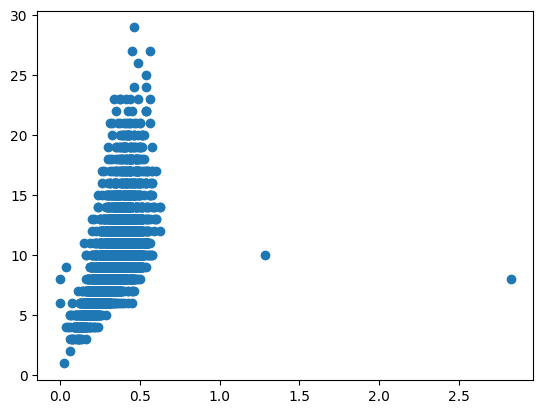

In [ ]:
from matplotlib import pyplot as plt

plt.scatter(df['Height'], df['Age'])

In [ ]:
np.percentile(df['Weight'], 99), df['Weight'].max()

(60.717825119999986, 80.10151225)

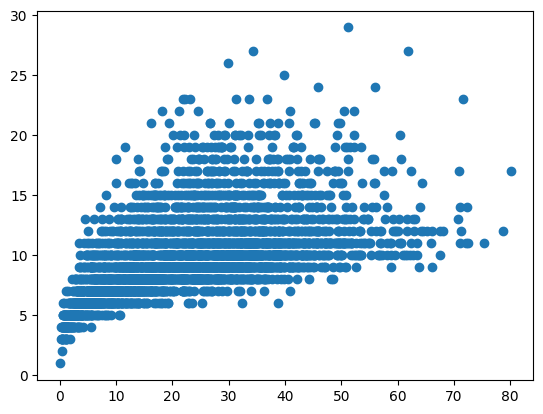

In [ ]:
plt.scatter(df['Weight'], df['Age'])

In [ ]:
np.percentile(df['Shell Weight'], 99), df['Shell Weight'].max()

(17.57669, 28.4912475)

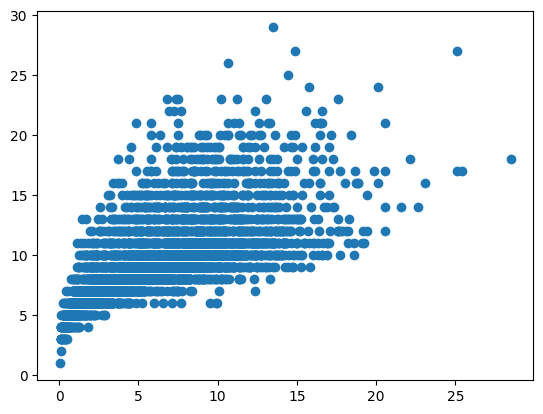

In [ ]:
plt.scatter(df['Shell Weight'], df['Age'])

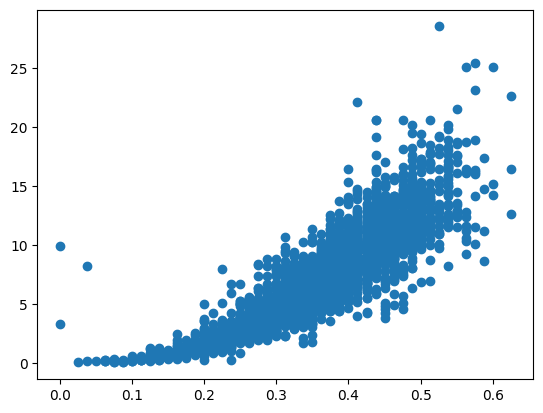

In [ ]:
df_clean = df.copy()
df_clean = df_clean[df_clean['Height'] < 1]

plt.scatter(df_clean['Height'], df_clean['Shell Weight'])

Оставим только объекты с Height < 1.

In [ ]:
df_encoded = df_encoded[df_encoded['Height'] < 1]

X_enc = df_encoded.drop(['Age'], axis=1)
y_enc = df_encoded['Age']

X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(X_enc, y_enc, test_size=0.25, random_state=42)

In [ ]:
model.fit(X_train_enc, y_train_enc)

pred_enc_clean = model.predict(X_test_enc)

In [ ]:
r2_score(y_test_enc, pred_enc_clean)

0.5360536896988822

In [ ]:
df_encoded.head()

,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age,Sex_I,Sex_M
0,1.4375,1.1750,0.4125,24.635715,12.332033,5.584852,6.747181,9,0,0
1,0.8875,0.6500,0.2125,5.400580,2.296310,1.374951,1.559222,6,0,1
2,1.0375,0.7750,0.2500,7.952035,3.231843,1.601747,2.764076,6,1,0
3,1.1750,0.8875,0.2500,13.480187,4.748541,2.282135,5.244657,10,0,0
4,0.8875,0.6625,0.2125,6.903103,3.458639,1.488349,1.700970,6,1,0


# Занятие 2

# Улучшение модели: Feature Engineering

## Шаг 1. Изучение зависимостей целевой переменной от признаков

Length


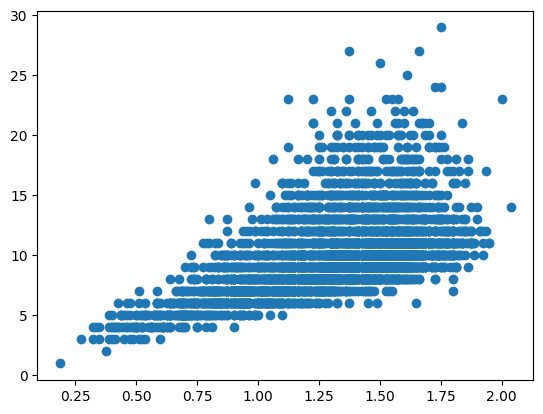

Diameter


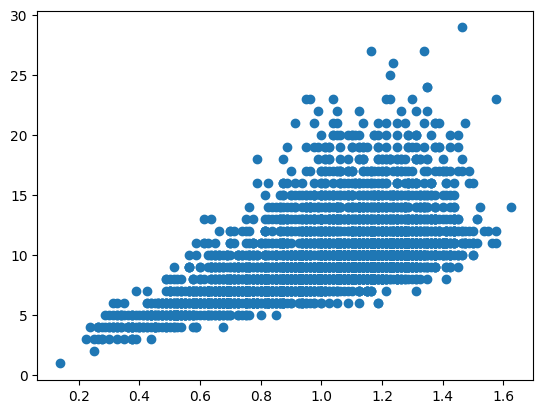

Height


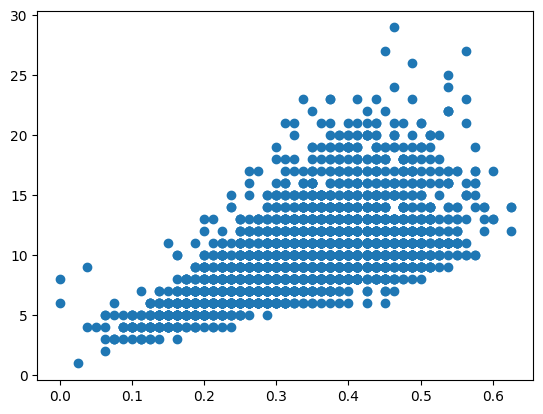

Weight


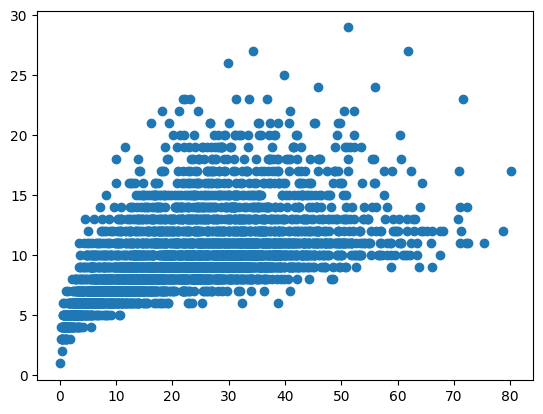

Shucked Weight


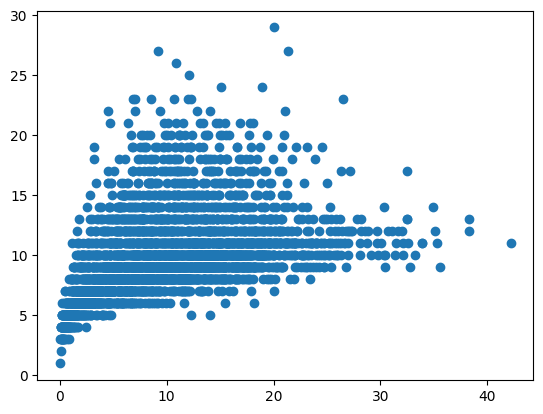

Viscera Weight


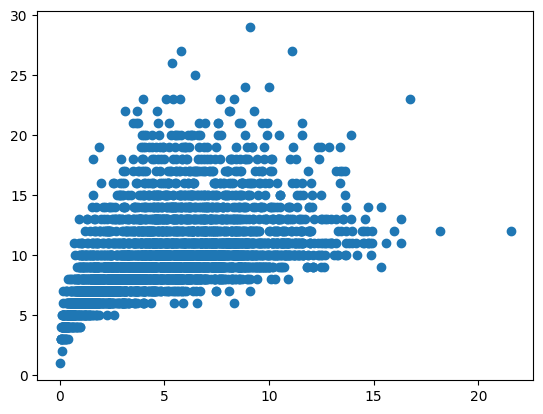

Shell Weight


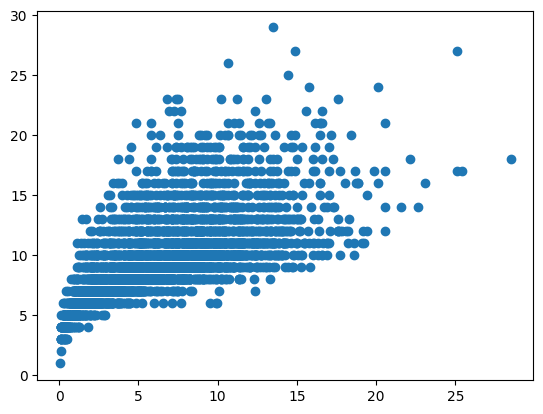

Age


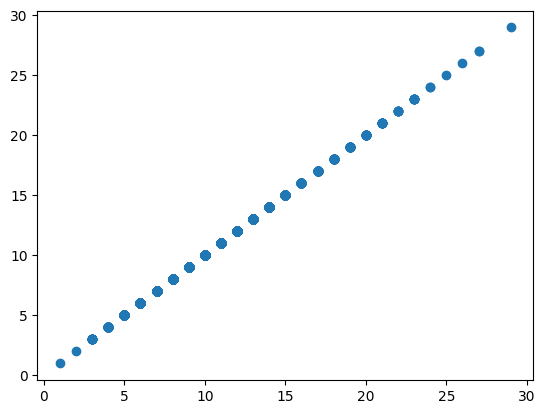

Sex_I


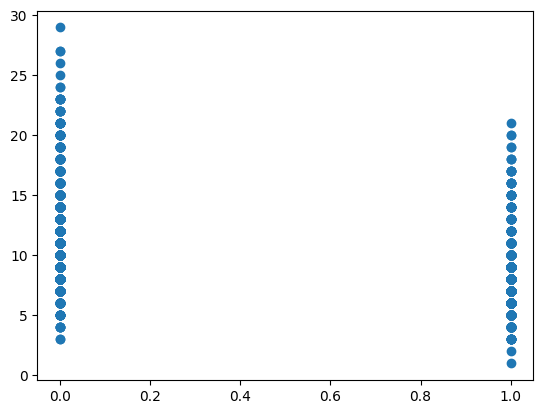

Sex_M


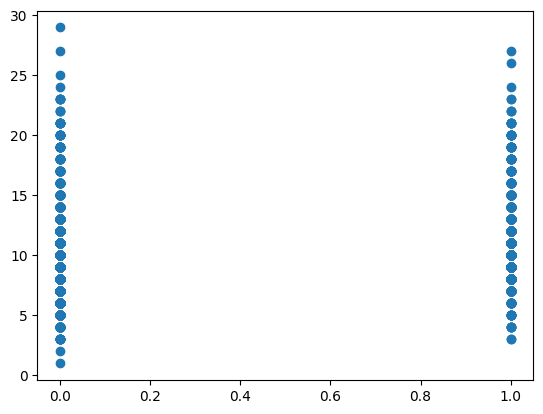

In [ ]:
for c in df_encoded.columns:
    print(c)
    plt.scatter(df_encoded[c], df_encoded['Age'])
    plt.show()

<Axes: >

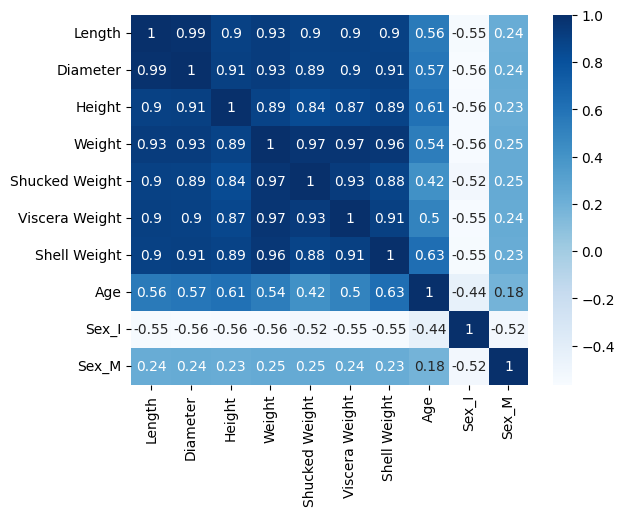

In [ ]:
corr = df_encoded.corr() # матрица корреляций

sns.heatmap(corr, cmap="Blues", annot=True)

<Axes: >

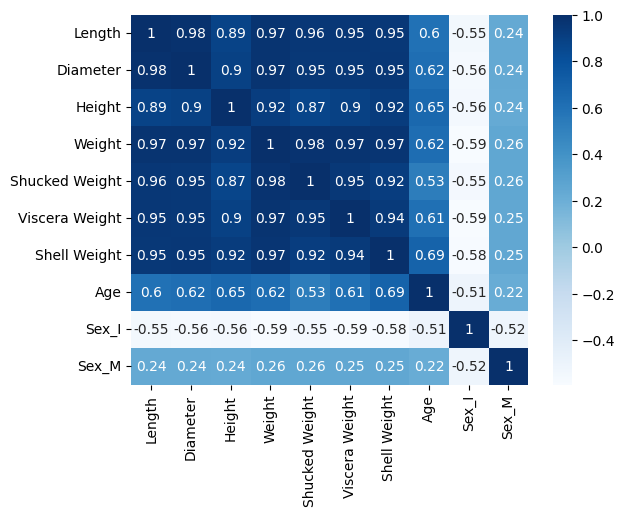

In [ ]:
corr = df_encoded.corr(method='spearman') # матрица корреляций

sns.heatmap(corr, cmap="Blues", annot=True)

Мы видим некоторые нелинейные зависимости - это видно и по графикам, и по соотношение корреляций Пирсона и Спирмена.

Сделаем логарифмическое преобразование и снова посмотрим на вид зависимостей.

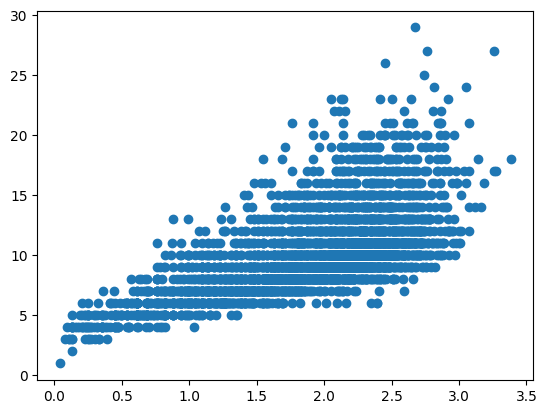

In [ ]:
plt.scatter(np.log1p(df['Shell Weight']), df['Age'])

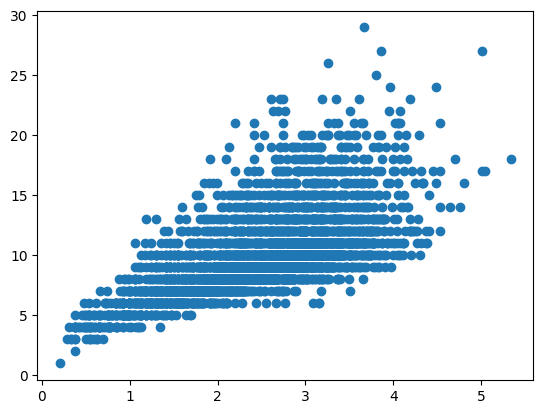

In [ ]:
plt.scatter(df['Shell Weight'] ** 0.5, df['Age'])

In [ ]:
np.corrcoef(df['Shell Weight'], df['Age'])[0][1]

0.625194993696926

In [ ]:
np.corrcoef(df['Shell Weight'] ** 0.5, df['Age'])[0][1]

0.6459172586657297

In [ ]:
np.corrcoef(np.log1p(df['Shell Weight']), df['Age'])[0][1]

0.6443251909775604

In [ ]:
def get_dependency(column):
    print(np.corrcoef(df_encoded[column], df_encoded['Age'])[0][1])
    print(np.corrcoef(df_encoded[column] ** 0.5, df_encoded['Age'])[0][1])
    print(np.corrcoef(np.log1p(df_encoded[column]), df_encoded['Age'])[0][1])

for c in df_encoded.columns:
    print(c)
    get_dependency(c)

Length
0.5550887258504872
0.5597846041262801
0.5601024745905809
Diameter
0.5739869150824956
0.5775208502104723
0.5775487540155613
Height
0.6075020940967503
0.6060705706621877
0.6093475476613257
Weight
0.5393245343763385
0.5755337380944261
0.5864536923286908
Shucked Weight
0.4193635431072341
0.47511810870366156
0.5019798991199763
Viscera Weight
0.5017731032932152
0.5464194735876937
0.5597690712398575
Shell Weight
0.6254533763469959
0.6461004194337645
0.64445517420484
Age
1.0
0.9919083274989079
0.9730878315944425
Sex_I
-0.43811383397793735
-0.43811383397793735
-0.43811383397793785
Sex_M
0.18227739695093703
0.18227739695093703
0.18227739695093706


In [ ]:
df_encoded['log Weight'] = np.log1p(df_encoded['Weight'])
df_encoded['log Shucked Weight'] = np.log1p(df_encoded['Shucked Weight'])
df_encoded['log Viscera Weight'] = np.log1p(df_encoded['Viscera Weight'])

df_encoded.drop(['Weight', 'Shucked Weight', 'Viscera Weight'], axis=1, inplace=True)

In [ ]:
X_enc = df_encoded.drop(['Age'], axis=1)
y_enc = df_encoded['Age']

X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(X_enc, y_enc, test_size=0.25, random_state=42)

In [ ]:
model.fit(X_train_enc, y_train_enc)

pred_enc_clean = model.predict(X_test_enc)

r2_score(y_test_enc, pred_enc_clean)

0.5518882667932137

После логарфмирования некоторых признаков удалось увеличить качество модели с 0.536 до 0.551.

## Шаг 2: изучение попарных зависимостей - полиномиальные признаки

Добавим полиномиальных признаков степени 2 и 3.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import Ridge, Lasso

model = LinearRegression()

pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2)),
    ('lin_reg', model)
])

# Обучаем модель
pipeline.fit(X_train_enc, y_train_enc)

# Делаем предсказания
y_pred = pipeline.predict(X_test_enc)

In [ ]:
r2_score(y_test_enc, y_pred)

0.5784314324623029

In [ ]:
pred_train = pipeline.predict(X_train_enc)

r2_score(y_train_enc, pred_train)

0.5941055812836038

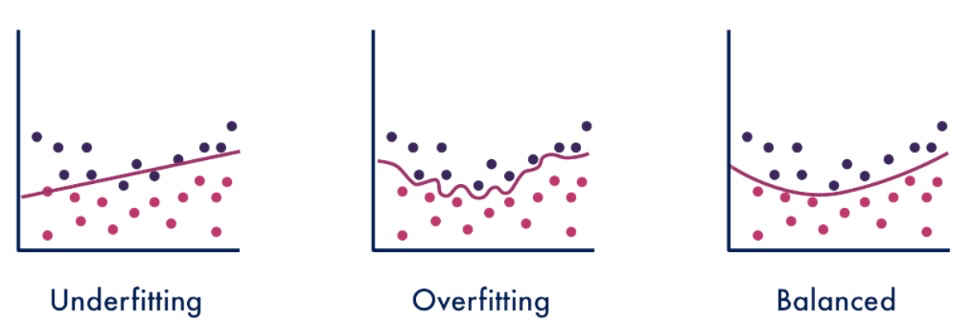

Переобучились =(

In [ ]:
# Получаем имена полиномиальных признаков
poly_features = pipeline.named_steps['poly_features']
feature_names = poly_features.get_feature_names_out()

# Получаем веса линейной регрессии
lin_reg = pipeline.named_steps['lin_reg']
coefficients = lin_reg.coef_
intercept = lin_reg.intercept_

# Создаем DataFrame с весами признаков
weights_df = pd.DataFrame({
    'Feature': feature_names,
    'Weight': coefficients
}).sort_values(by='Weight')

In [ ]:
weights_df

,Feature,Weight
113,Diameter Height log Shucked Weight,-547.960109
71,Length Diameter log Viscera Weight,-509.864702
70,Length Diameter log Shucked Weight,-507.438421
61,Length^2 log Weight,-464.220744
20,Diameter Height,-459.265586
...,...,...
57,Length^2 Height,345.724465
63,Length^2 log Viscera Weight,371.237980
3,Height,395.162185
69,Length Diameter log Weight,817.845422


Добавим регуляризацию (модели Ridge, Lasso).

Эти модели требуют также масштабирования признаков.

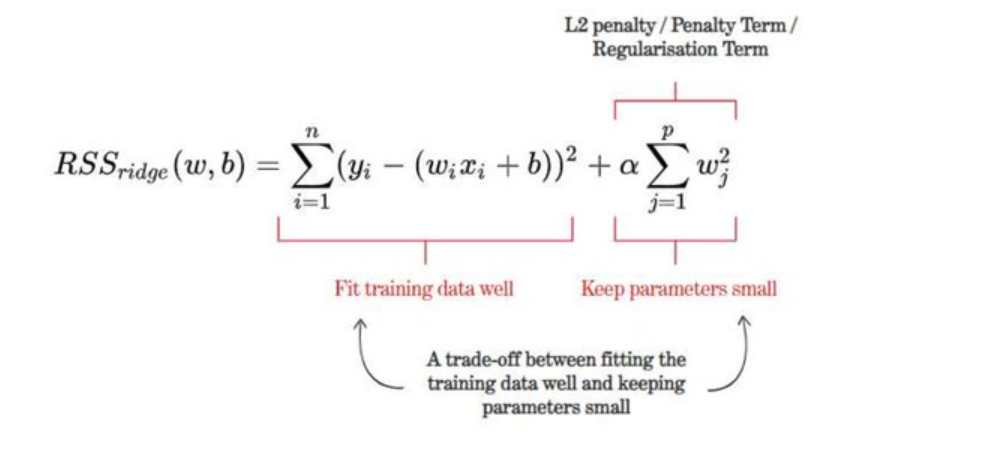

In [ ]:
model = Ridge(alpha = 0.01)

pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=3)),
    ('scaler', MinMaxScaler()),
    ('lin_reg', model)
])

# Обучаем модель
pipeline.fit(X_train_enc, y_train_enc)

# Делаем предсказания
pred_train = pipeline.predict(X_train_enc)
y_pred = pipeline.predict(X_test_enc)

r2_score(y_train_enc, pred_train), r2_score(y_test_enc, y_pred)

(0.5902962715376525, 0.5729041500787566)

Удалось не переобучиться и поднять качество с 0.551 до 0.572.

In [ ]:
# Получаем имена полиномиальных признаков
poly_features = pipeline.named_steps['poly_features']
feature_names = poly_features.get_feature_names_out()

# Получаем веса линейной регрессии
lin_reg = pipeline.named_steps['lin_reg']
coefficients = lin_reg.coef_
intercept = lin_reg.intercept_

# Создаем DataFrame с весами признаков
weights_df = pd.DataFrame({
    'Feature': feature_names,
    'Weight': coefficients
}).sort_values(by='Weight')

weights_df

Проверим быстрое и самое популярное решение - CatBoost.

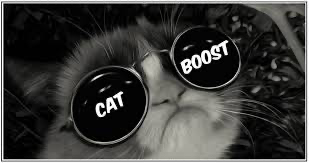

In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 MB 5.7 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor

cb = CatBoostRegressor(n_estimators=100)

cb.fit(X_train_enc, y_train_enc)

pred_train = cb.predict(X_train_enc)
y_pred = cb.predict(X_test_enc)

r2_score(y_train_enc, pred_train), r2_score(y_test_enc, y_pred)

Learning rate set to 0.315256
0:	learn: 2.8651109	total: 50.8ms	remaining: 5.03s
1:	learn: 2.6401645	total: 54.6ms	remaining: 2.67s
2:	learn: 2.5035337	total: 57ms	remaining: 1.84s
3:	learn: 2.4002244	total: 59.5ms	remaining: 1.43s
4:	learn: 2.3377827	total: 62ms	remaining: 1.18s
5:	learn: 2.2857404	total: 64.4ms	remaining: 1.01s
6:	learn: 2.2507031	total: 66.8ms	remaining: 888ms
7:	learn: 2.2186993	total: 69.3ms	remaining: 797ms
8:	learn: 2.1885222	total: 71.8ms	remaining: 726ms
9:	learn: 2.1623722	total: 75.2ms	remaining: 676ms
10:	learn: 2.1386216	total: 78ms	remaining: 631ms
11:	learn: 2.1161604	total: 80.7ms	remaining: 592ms
12:	learn: 2.1031781	total: 84.3ms	remaining: 564ms
13:	learn: 2.0873833	total: 86.9ms	remaining: 534ms
14:	learn: 2.0742033	total: 94.2ms	remaining: 534ms
15:	learn: 2.0617778	total: 97ms	remaining: 509ms
16:	learn: 2.0510505	total: 100ms	remaining: 489ms
17:	learn: 2.0466010	total: 104ms	remaining: 472ms
18:	learn: 2.0320782	total: 107ms	remaining: 455ms
19:

(0.7742588836057529, 0.5495117576489992)

Успеха нет. Двигаемся дальше.

## Шаг 3: отбор признаков

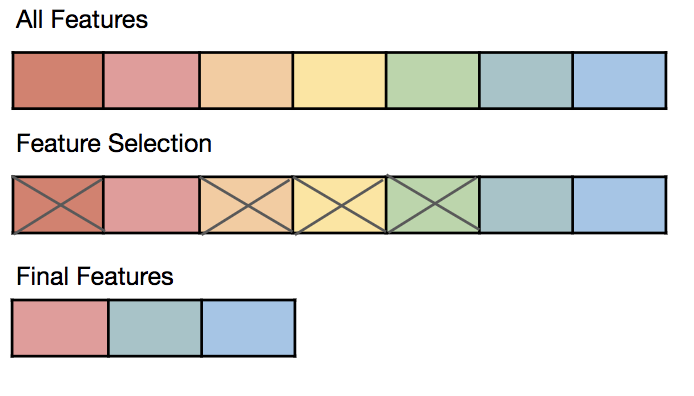

In [ ]:
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import SelectKBest, f_classif

model = Ridge(alpha = 0.01)

pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=3)),
    ('scaler', MinMaxScaler()),
    ('selector', SelectKBest(score_func=f_classif, k=180)),
    ('lin_reg', model)
])

# Обучаем модель
pipeline.fit(X_train_enc, y_train_enc)

# Делаем предсказания
pred_train = pipeline.predict(X_train_enc)
y_pred = pipeline.predict(X_test_enc)

r2_score(y_train_enc, pred_train), r2_score(y_test_enc, y_pred)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [  0  41  86 122 150 171 186 190 191 192 193] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


(0.5973279291447873, 0.5767081961637861)

Удалось еще немного поднять качество - с 0.572 до 0.576

## Шаг 4: анализ решения => смена функции потерь

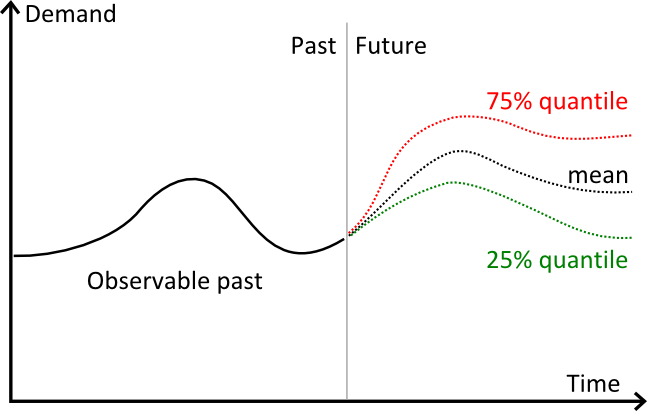

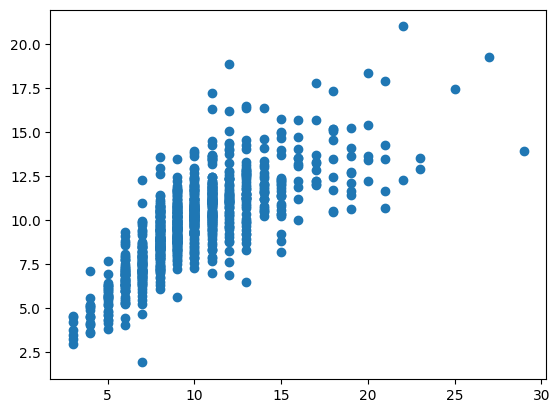

In [ ]:
plt.scatter(y_test_enc, y_pred)

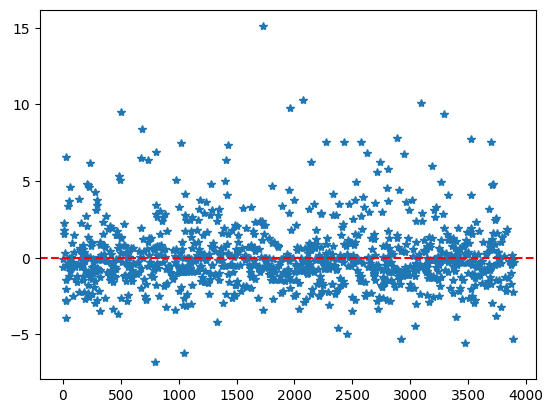

In [ ]:
plt.plot(y_test_enc-y_pred,'*')
plt.axhline(y=0, color='red', linestyle='--')

Прогнозы в среднем занижены, поэтому будем прогнозировать 60%-квантиль целевой переменной, то есть сознательно будем завышать прогноз.

In [ ]:
from sklearn.linear_model import QuantileRegressor

model = QuantileRegressor(quantile=0.6, solver="highs", alpha=0.00001)

pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=3)),
    ('scaler', MinMaxScaler()),
    ('selector', SelectKBest(score_func=f_classif, k=180)),
    ('lin_reg', model)
])

# Обучаем модель
pipeline.fit(X_train_enc, y_train_enc)

# Делаем предсказания
pred_train = pipeline.predict(X_train_enc)
y_pred = pipeline.predict(X_test_enc)

r2_score(y_train_enc, pred_train), r2_score(y_test_enc, y_pred)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [  0  41  86 122 150 171 186 190 191 192 193] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


(0.5895109152453853, 0.5786128435019084)

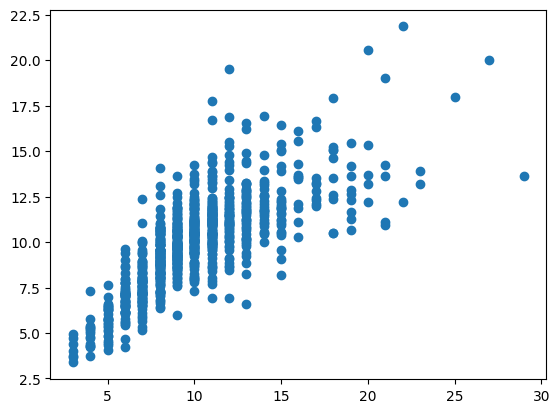

In [ ]:
plt.scatter(y_test_enc, y_pred)

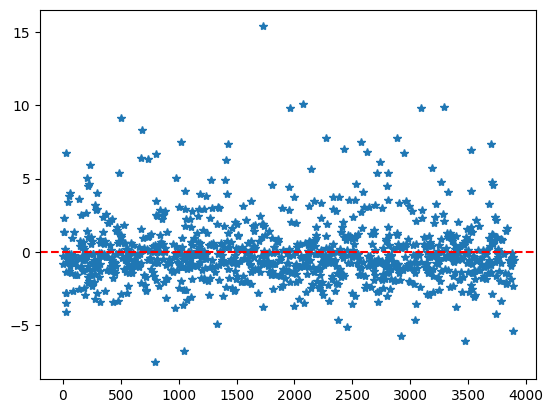

In [ ]:
plt.plot(y_test_enc-y_pred,'*')
plt.axhline(y=0, color='red', linestyle='--')

Удалось поднять качество с 0.572 до 0.584 (?).

## Итоги:

Базовая линейная регрессия показывает качество $R2 = 0.511$

**Были сделаны следующие шаги, каждый из которых улучшил качество:**

* One-hot кодирование категориального признака `Sex`

* Удаление двух объектов (очевидные выбросы или ошибки)

* Логарифмирование нескольких признаков

* Добавление полиномиальных признаков степени 2 и 3 с последующей регуляризацией

* Добавление регуляризации

* Отбор признаков при помощи SelectKBest

* Смена функции потерь с MSE на квантильные потери с $q=0.6$.

Итоговый результат: $R2 = 0.584$

**Было проведено множество экспериментов, но в ноутбуке отражены только удачные!! Не любой подход улучшает качество.**

**Стандартное быстрое решение - CatBoost - не всегда спасает.**